In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR

DATASET_PATH = r"Dataset/Dataset"
MODEL_SAVE_PATH = "SavedModels"
MODEL_NAME = "PN2_Vox002_CW20_Augmented.pth"
EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Training on: {DEVICE}")

class TreePointCloudDataset(Dataset):
    def __init__(self, file_paths, augment=False):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path, allow_pickle=True).item()
        
        points = data['points'] 
        labels = data['labels']
        
        if self.augment:
            theta = np.random.uniform(0, 2 * np.pi)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta), 0],
                [np.sin(theta), np.cos(theta), 0],
                [0, 0, 1]
            ])
            points = np.dot(points.T, rotation_matrix).T
            
            noise = np.random.normal(0, 0.002, size=points.shape)
            points += noise

        points = torch.tensor(points, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)
        
        return points, labels, file_path

Training on: cuda


In [2]:
def square_distance(src, dst):
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]

def farthest_point_sample(xyz, npoint):
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).to(device).view(1, 1, N).repeat([B, S, 1])
    sqrdists = square_distance(new_xyz, xyz)
    group_idx[sqrdists > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat([1, 1, nsample])
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx

def sample_and_group(npoint, radius, nsample, xyz, points):
    B, N, C = xyz.shape
    S = npoint
    fps_idx = farthest_point_sample(xyz, npoint)
    new_xyz = index_points(xyz, fps_idx)
    idx = query_ball_point(radius, nsample, xyz, new_xyz)
    grouped_xyz = index_points(xyz, idx)
    grouped_xyz_norm = grouped_xyz - new_xyz.view(B, S, 1, C)
    
    if points is not None:
        grouped_points = index_points(points, idx)
        new_points = torch.cat([grouped_xyz_norm, grouped_points], dim=-1)
    else:
        new_points = grouped_xyz_norm
    return new_xyz, new_points

In [3]:
class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp):
        super(PointNetSetAbstraction, self).__init__()
        self.npoint = npoint
        self.radius = radius
        self.nsample = nsample
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm2d(out_channel))
            last_channel = out_channel

    def forward(self, xyz, points):
        new_xyz, new_points = sample_and_group(self.npoint, self.radius, self.nsample, xyz, points)
        new_points = new_points.permute(0, 3, 2, 1) 
        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            new_points = F.relu(bn(conv(new_points)))
        new_points = torch.max(new_points, 2)[0] 
        new_points = new_points.permute(0, 2, 1) 
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super(PointNetFeaturePropagation, self).__init__()
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel

    def forward(self, xyz1, xyz2, points1, points2):
        B, N, C = xyz1.shape
        _, S, _ = xyz2.shape

        if S == 1:
            interpolated_points = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = torch.sum(dist_recip, dim=2, keepdim=True)
            weight = dist_recip / norm 
            interpolated_points = torch.sum(index_points(points2, idx) * weight.view(B, N, 3, 1), dim=2)

        if points1 is not None:
            new_points = torch.cat([points1, interpolated_points], dim=-1) 
        else:
            new_points = interpolated_points

        new_points = new_points.permute(0, 2, 1) 
        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            new_points = F.relu(bn(conv(new_points)))
        
        new_points = new_points.permute(0, 2, 1) 
        return new_points

class PointNetSegmentation(nn.Module):
    def __init__(self, num_classes=2):
        super(PointNetSegmentation, self).__init__()
        self.sa1 = PointNetSetAbstraction(1024, 0.1, 32, 3 + 3, [32, 32, 64])
        self.sa2 = PointNetSetAbstraction(256, 0.2, 32, 64 + 3, [64, 64, 128])
        self.sa3 = PointNetSetAbstraction(64, 0.4, 32, 128 + 3, [128, 128, 256])
        self.sa4 = PointNetSetAbstraction(16, 0.8, 32, 256 + 3, [256, 256, 512])
        
        self.fp4 = PointNetFeaturePropagation(512 + 256, [256, 256])
        self.fp3 = PointNetFeaturePropagation(256 + 128, [256, 256])
        self.fp2 = PointNetFeaturePropagation(256 + 64, [128, 128])
        self.fp1 = PointNetFeaturePropagation(128 + 3, [128, 128, 128])
        
        self.conv1 = nn.Conv1d(128, 128, 1)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(128, num_classes, 1)

    def forward(self, xyz):
        xyz = xyz.permute(0, 2, 1)
        l0_points = xyz
        l0_xyz = xyz

        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        l4_xyz, l4_points = self.sa4(l3_xyz, l3_points)

        l3_points = self.fp4(l3_xyz, l4_xyz, l3_points, l4_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, l0_points, l1_points)

        x = l0_points.permute(0, 2, 1)
        x = self.drop1(F.relu(self.bn1(self.conv1(x))))
        x = self.conv2(x)
        return x

In [4]:
npy_pattern = os.path.join(DATASET_PATH, "tree_*", "Filtered__noGrass", "voxelized_selected", "*.npy")
all_npy_files = glob.glob(npy_pattern)
print(f"Found {len(all_npy_files)} files.")

train_paths, test_paths = train_test_split(all_npy_files, test_size=0.15, random_state=42)
train_paths, val_paths = train_test_split(train_paths, test_size=0.18, random_state=42)

train_dataset = TreePointCloudDataset(train_paths, augment=True)
val_dataset = TreePointCloudDataset(val_paths, augment=False)
test_dataset = TreePointCloudDataset(test_paths, augment=False)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Found 1088 files.


Epoch 1/50 [LR: 0.00100]: 100%|██████████| 757/757 [09:26<00:00,  1.34it/s, Loss=0.0296]


Epoch [1/50] -> Loss: 0.0673, Train Acc: 0.8317, Val Acc: 0.8850
--- Best model saved (Val Acc: 0.8850) ---


Epoch 2/50 [LR: 0.00100]: 100%|██████████| 757/757 [11:03<00:00,  1.14it/s, Loss=0.0091]


Epoch [2/50] -> Loss: 0.0408, Train Acc: 0.9129, Val Acc: 0.5816


Epoch 3/50 [LR: 0.00100]: 100%|██████████| 757/757 [08:22<00:00,  1.51it/s, Loss=0.0715]


...

Epoch [48/50] -> Loss: 0.0010, Train Acc: 0.9993, Val Acc: 0.8276


Epoch 49/50 [LR: 0.00001]: 100%|██████████| 757/757 [09:53<00:00,  1.27it/s, Loss=0.0004]


Epoch [49/50] -> Loss: 0.0010, Train Acc: 0.9993, Val Acc: 0.7074


Epoch 50/50 [LR: 0.00001]: 100%|██████████| 757/757 [10:04<00:00,  1.25it/s, Loss=0.0003]


Epoch [50/50] -> Loss: 0.0010, Train Acc: 0.9993, Val Acc: 0.5834


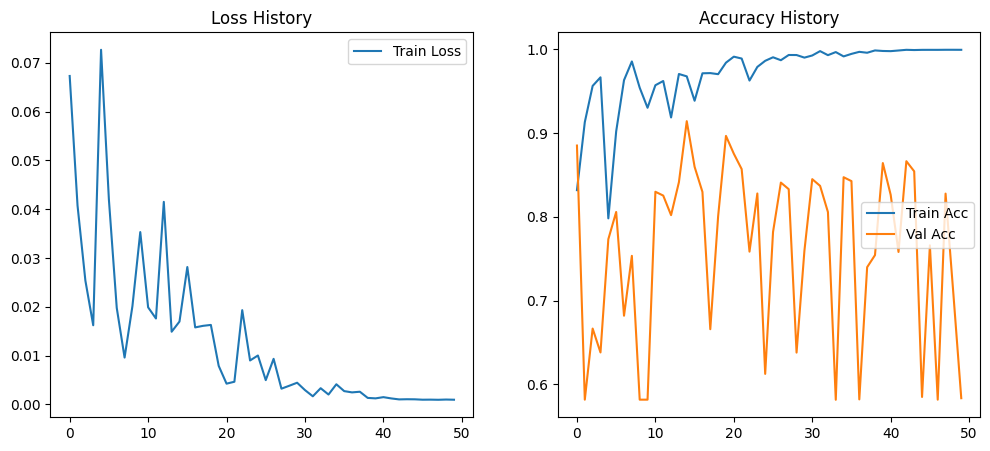

In [5]:
model = PointNetSegmentation(num_classes=2).to(DEVICE)
weights = torch.tensor([1.0, 20.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

train_losses, train_accs, val_accs = [], [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    current_lr = optimizer.param_groups[0]['lr']
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [LR: {current_lr:.5f}]")
    for points, labels, _ in pbar:
        points, labels = points.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(points)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
        
        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    scheduler.step() 

    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(correct / total)
    
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for points, labels, _ in val_loader:
            points, labels = points.to(DEVICE), labels.to(DEVICE)
            outputs = model(points)
            preds = torch.argmax(outputs, dim=1)
            
            val_correct += (preds == labels).sum().item()
            val_total += labels.numel()
            
    val_acc = val_correct / val_total if val_total > 0 else 0
    val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, MODEL_NAME))
        print(f"--- Best model saved (Val Acc: {val_acc:.4f}) ---")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [6]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import open3d as o3d

DATASET_PATH = r"Dataset/Dataset"
MODEL_PATH = os.path.join("SavedModels", "PN2_Vox002_CW20_Augmented.pth")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TreePointCloudDataset(Dataset):
    def __init__(self, file_paths, augment=False):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path, allow_pickle=True).item()
        
        points = data['points'] 
        labels = data['labels']
        
        if self.augment:
            theta = np.random.uniform(0, 2 * np.pi)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta), 0],
                [np.sin(theta), np.cos(theta), 0],
                [0, 0, 1]
            ])
            points = np.dot(points.T, rotation_matrix).T
            
            noise = np.random.normal(0, 0.002, size=points.shape)
            points += noise

        points = torch.tensor(points, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)
        
        return points, labels, file_path

def square_distance(src, dst):
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]

def farthest_point_sample(xyz, npoint):
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).to(device).view(1, 1, N).repeat([B, S, 1])
    sqrdists = square_distance(new_xyz, xyz)
    group_idx[sqrdists > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat([1, 1, nsample])
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx

def sample_and_group(npoint, radius, nsample, xyz, points):
    B, N, C = xyz.shape
    S = npoint
    fps_idx = farthest_point_sample(xyz, npoint)
    new_xyz = index_points(xyz, fps_idx)
    idx = query_ball_point(radius, nsample, xyz, new_xyz)
    grouped_xyz = index_points(xyz, idx)
    grouped_xyz_norm = grouped_xyz - new_xyz.view(B, S, 1, C)
    
    if points is not None:
        grouped_points = index_points(points, idx)
        new_points = torch.cat([grouped_xyz_norm, grouped_points], dim=-1)
    else:
        new_points = grouped_xyz_norm
    return new_xyz, new_points

class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp):
        super(PointNetSetAbstraction, self).__init__()
        self.npoint = npoint
        self.radius = radius
        self.nsample = nsample
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm2d(out_channel))
            last_channel = out_channel

    def forward(self, xyz, points):
        new_xyz, new_points = sample_and_group(self.npoint, self.radius, self.nsample, xyz, points)
        new_points = new_points.permute(0, 3, 2, 1) 
        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            new_points = F.relu(bn(conv(new_points)))
        new_points = torch.max(new_points, 2)[0] 
        new_points = new_points.permute(0, 2, 1) 
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super(PointNetFeaturePropagation, self).__init__()
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel

    def forward(self, xyz1, xyz2, points1, points2):
        B, N, C = xyz1.shape
        _, S, _ = xyz2.shape

        if S == 1:
            interpolated_points = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = torch.sum(dist_recip, dim=2, keepdim=True)
            weight = dist_recip / norm 
            interpolated_points = torch.sum(index_points(points2, idx) * weight.view(B, N, 3, 1), dim=2)

        if points1 is not None:
            new_points = torch.cat([points1, interpolated_points], dim=-1) 
        else:
            new_points = interpolated_points

        new_points = new_points.permute(0, 2, 1) 
        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            new_points = F.relu(bn(conv(new_points)))
        
        new_points = new_points.permute(0, 2, 1) 
        return new_points

class PointNetSegmentation(nn.Module):
    def __init__(self, num_classes=2):
        super(PointNetSegmentation, self).__init__()
        self.sa1 = PointNetSetAbstraction(1024, 0.1, 32, 3 + 3, [32, 32, 64])
        self.sa2 = PointNetSetAbstraction(256, 0.2, 32, 64 + 3, [64, 64, 128])
        self.sa3 = PointNetSetAbstraction(64, 0.4, 32, 128 + 3, [128, 128, 256])
        self.sa4 = PointNetSetAbstraction(16, 0.8, 32, 256 + 3, [256, 256, 512])
        
        self.fp4 = PointNetFeaturePropagation(512 + 256, [256, 256])
        self.fp3 = PointNetFeaturePropagation(256 + 128, [256, 256])
        self.fp2 = PointNetFeaturePropagation(256 + 64, [128, 128])
        self.fp1 = PointNetFeaturePropagation(128 + 3, [128, 128, 128])
        
        self.conv1 = nn.Conv1d(128, 128, 1)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(128, num_classes, 1)

    def forward(self, xyz):
        xyz = xyz.permute(0, 2, 1)
        l0_points = xyz
        l0_xyz = xyz

        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        l4_xyz, l4_points = self.sa4(l3_xyz, l3_points)

        l3_points = self.fp4(l3_xyz, l4_xyz, l3_points, l4_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, l0_points, l1_points)

        x = l0_points.permute(0, 2, 1)
        x = self.drop1(F.relu(self.bn1(self.conv1(x))))
        x = self.conv2(x)
        return x

npy_pattern = os.path.join(DATASET_PATH, "tree_*", "Filtered__noGrass", "voxelized_selected", "*.npy")
all_npy_files = glob.glob(npy_pattern)

_, test_paths = train_test_split(all_npy_files, test_size=0.15, random_state=42)
test_dataset = TreePointCloudDataset(test_paths, augment=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model = PointNetSegmentation(num_classes=2).to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    print(f"Loaded augmented model: {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

model.eval()

global_tp, global_tn, global_fp, global_fn = 0, 0, 0, 0
file_results = []

for points, labels, paths in tqdm(test_loader, desc="Evaluating"):
    points, labels = points.to(DEVICE), labels.to(DEVICE)
    
    with torch.no_grad():
        outputs = model(points)
    
    preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()
    labels_np = labels.squeeze(0).cpu().numpy()
    points_np = points.squeeze(0).cpu().numpy()
    file_path = paths[0]
    
    tp = np.sum((preds == 1) & (labels_np == 1))
    tn = np.sum((preds == 0) & (labels_np == 0))
    fp = np.sum((preds == 1) & (labels_np == 0))
    fn = np.sum((preds == 0) & (labels_np == 1))
    
    global_tp += tp
    global_tn += tn
    global_fp += fp
    global_fn += fn
    
    union = tp + fp + fn
    iou = tp / union if union > 0 else 1.0 
    
    file_results.append({
        'path': os.path.abspath(file_path),
        'iou': iou,
        'preds': preds,
        'labels': labels_np,
        'points': points_np
    })

total_points = global_tp + global_tn + global_fp + global_fn
accuracy = (global_tp + global_tn) / total_points if total_points > 0 else 0
precision = global_tp / (global_tp + global_fp) if (global_tp + global_fp) > 0 else 0
recall = global_tp / (global_tp + global_fn) if (global_tp + global_fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
global_iou = global_tp / (global_tp + global_fp + global_fn) if (global_tp + global_fp + global_fn) > 0 else 0

print("\n" + "="*50)
print("FINAL TEST SET METRICS (AUGMENTED MODEL)")
print("="*50)
print(f"Total Points Analysed: {total_points:,}")
print(f"True Positives (TP):   {global_tp:,}")
print(f"True Negatives (TN):   {global_tn:,}")
print(f"False Positives (FP):  {global_fp:,}")
print(f"False Negatives (FN):  {global_fn:,}")
print("-" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")
print(f"mIoU:      {global_iou:.4f}")
print("="*50)

file_results.sort(key=lambda x: x['iou'])
worst_file = file_results[0]
best_file = file_results[-1]

def visualize_prediction(points, labels, preds, title):
    colors = np.zeros((points.shape[1], 3)) 
    colors[(labels == 0) & (preds == 0)] = [0.7, 0.7, 0.7] # True Negative
    colors[(labels == 1) & (preds == 1)] = [0.0, 1.0, 0.0] # True Positive
    colors[(labels == 1) & (preds == 0)] = [0.0, 0.0, 1.0] # False Negative
    colors[(labels == 0) & (preds == 1)] = [1.0, 0.0, 0.0] # False Positive

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.T) 
    pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.visualization.draw_geometries([pcd], window_name=title)

print(f"\n[WORST] Full Path: {worst_file['path']}")
print(f"[WORST] IoU: {worst_file['iou']:.4f}")
visualize_prediction(worst_file['points'], worst_file['labels'], worst_file['preds'], 
                     f"WORST | IoU: {worst_file['iou']:.4f}")

print(f"\n[BEST] Full Path: {best_file['path']}")
print(f"[BEST] IoU: {best_file['iou']:.4f}")
visualize_prediction(best_file['points'], best_file['labels'], best_file['preds'], 
                     f"BEST | IoU: {best_file['iou']:.4f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded augmented model: SavedModels\PN2_Vox002_CW20_Augmented.pth


Evaluating: 100%|██████████| 164/164 [01:43<00:00,  1.58it/s]



FINAL TEST SET METRICS (AUGMENTED MODEL)
Total Points Analysed: 865,365
True Positives (TP):   463,368
True Negatives (TN):   335,733
False Positives (FP):  19,989
False Negatives (FN):  46,275
--------------------------------------------------
Accuracy:  0.9234
Precision: 0.9586
Recall:    0.9092
F1-Score:  0.9333
mIoU:      0.8749

[WORST] Full Path: c:\Users\Lovro\Desktop\DIPLOMSKI\Dataset\Dataset\tree_1_V_0031\Filtered__noGrass\voxelized_selected\0.npy
[WORST] IoU: 0.4023

[BEST] Full Path: c:\Users\Lovro\Desktop\DIPLOMSKI\Dataset\Dataset\tree_1_V_0011\Filtered__noGrass\voxelized_selected\6.npy
[BEST] IoU: 1.0000
